# Tarea 3 De Procesamiento de Imagenes
El siguiente codigo tiene fragmentos de codigo sacado de las siguientes fuentes citadas:

Ignacio Vicente Marambio Zamora. 2025. *Tarea 1* [Codigo Fuente](https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672). UDP Canvas Tarea 1. [https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672](https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672).

mlacarrasco. 2025. *34_freq_noise.py* [Codigo Fuente](https://github.com/mlacarrasco/image_processing/blob/main/34_freq_noise.py). Github image_processing. [https://github.com/mlacarrasco/image_processing/blob/main/34_freq_noise.py](https://github.com/mlacarrasco/image_processing/blob/main/34_freq_noise.py).

mlacarrasco. 2025. *11_binarizacion.py* [Codigo Fuente](https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py). Github image_processing. [https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py](https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py).

## Programa Solicitado

### Parte 1
1. Utilice una imagen descargada de internet. De dicha imagen sólo utilice una sección de 512x512 píxeles (su imagen original debe ser igual o mayor a dicho tamaño).
2. Genere una imagen ruido frecuencial de 10Hz, una segunda imagen con 30Hz y una tercera imagen con 50Hz en forma vertical respectivamente (usted define la amplitud de la señal).
3. Genere una imagen que atenúe el ruido empleando filtros en la frecuencia para cada imagen del paso #2
### Parte 2
Genere una imagen con ruido empleando el siguiente código (no lo modifique). Luego desarrolle un
filtro en la frecuencia para reducir dicho ruido. Usted debe definir el filtro más apropiado.
``` python
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('cameraman.png',cv2.IMREAD_GRAYSCALE)
m = img.shape[0]
delta = 15
V = np.fix(np.linspace(delta,m-delta,delta)).astype('uint8')
img[V,:] = img[V,:]+50
img[:,V] = img[:,V]+50
plt.imshow(img, cmap='gray')
plt.show()
```

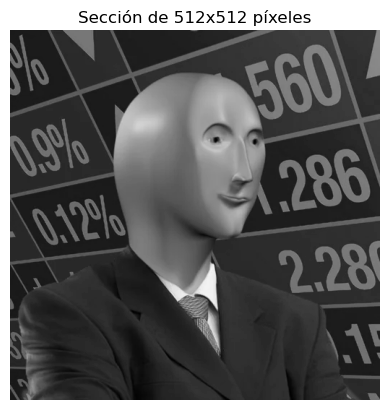

In [10]:
import cv2
import matplotlib.pyplot as plt
try:
    A = cv2.imread('stonks.png', 0)
    # Se selecciona una sección de 512x512 píxeles desde la esquina superior izquierda
    A = A[:512, :512]
    plt.imshow(A, cmap='gray')
    plt.title('Sección de 512x512 píxeles')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error: {e}")

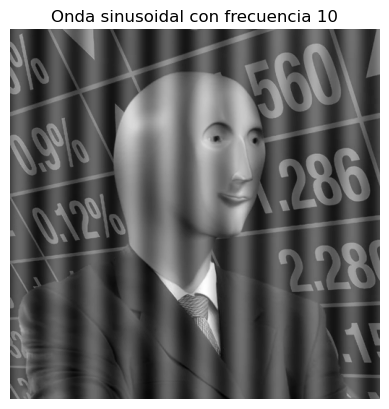

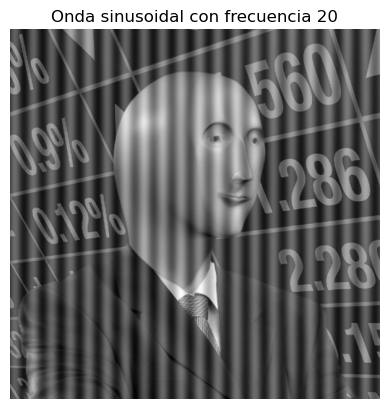

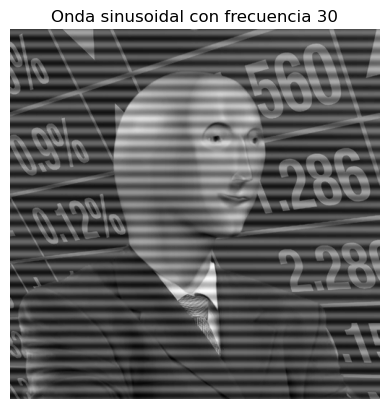

In [11]:
import numpy as np
import numpy.matlib

# La imagen A ya es escala de grises y tipo uint8
gray = A.astype(np.float32)
gray = cv2.normalize(gray, dst=None, alpha=0.0, beta=1.0, norm_type=cv2.NORM_MINMAX)

frec = {10,20,30} # Frecuencia de la onda sinusoidal
#vamos a crear ruido
def makenoise(gray, frec, orientation=0):
    if orientation == 1:
        # Ruido vertical: la onda varía a lo largo de las filas
        V = np.linspace(0, 1, num=gray.shape[0])
        Y = 0.2 * np.sin(2 * np.pi * frec * V)
        M = np.matlib.repmat(Y, gray.shape[1], 1).T
    else:
        # Ruido horizontal: la onda varía a lo largo de las columnas
        V = np.linspace(0, 1, num=gray.shape[1])
        Y = 0.2 * np.sin(2 * np.pi * frec * V)
        M = np.matlib.repmat(Y, gray.shape[0], 1)
    noise_img = np.add(M, gray)
    return noise_img

noised_images= []
for f in frec:
    if f == 30:
        # Para la frecuencia 30, se aplica una rotación de 90 grados
        noise_img = makenoise(gray, f, 1)
    else:
        noise_img = makenoise(gray, f)
    plt.imshow(noise_img, cmap='gray')
    plt.title(f'Onda sinusoidal con frecuencia {f}')
    plt.axis('off')
    plt.show()
    noised_images.append(noise_img)


#bloqueamos las frecuencias con ruido


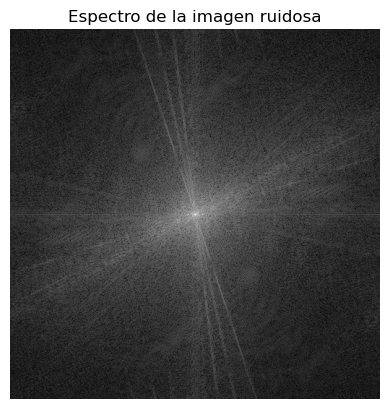

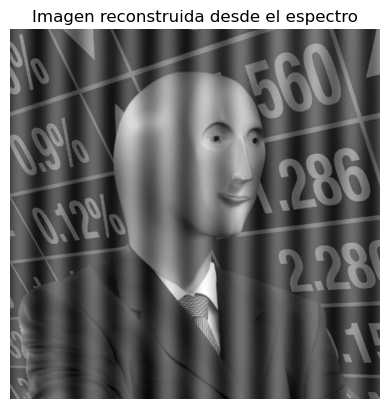

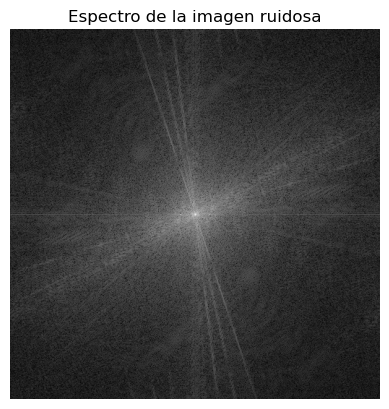

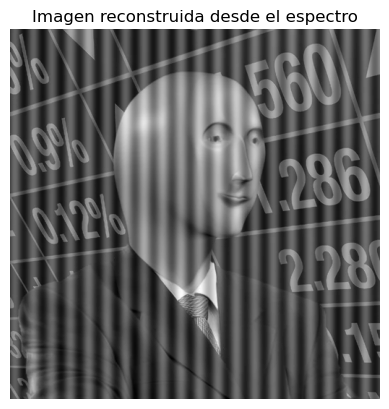

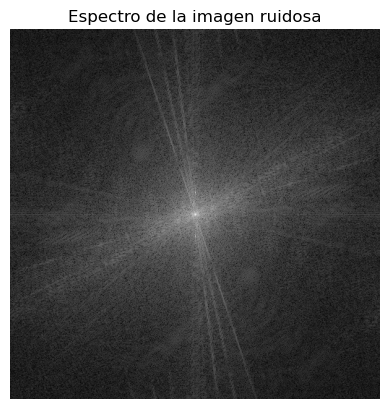

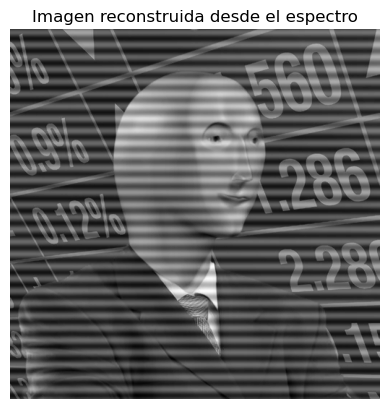

In [12]:
def get_star_spectrum(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    return fshift

def starreturn(star):
    f_ishift = np.fft.ifftshift(star)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)
    img_back = cv2.normalize(img_back, dst=None, alpha=0.0, beta=1.0, norm_type=cv2.NORM_MINMAX)
    return img_back

for i in noised_images:
# Mostrar el espectro de la imagen ruidosa
    spectrum = get_star_spectrum(i)
    plt.figure()
    plt.imshow(np.log(1 + np.abs(spectrum)), cmap='gray')
    plt.title('Espectro de la imagen ruidosa')
    plt.axis('off')
    plt.show()
    
    # Aplicar la función inversa y mostrar la imagen reconstruida
    img_back = starreturn(spectrum)
    plt.figure()
    plt.imshow(img_back, cmap='gray')
    plt.title('Imagen reconstruida desde el espectro')
    plt.axis('off')
    plt.show()


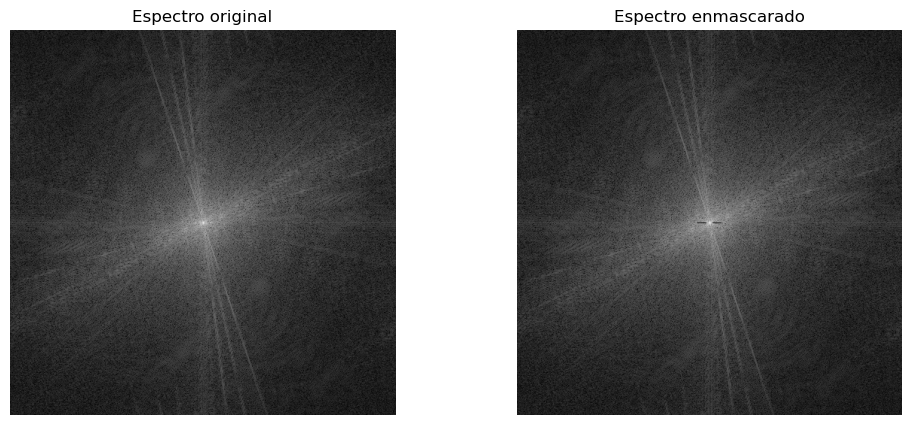

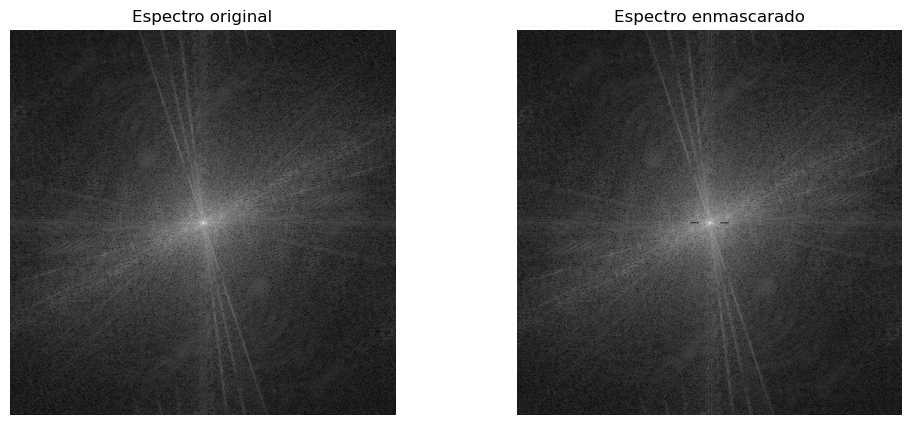

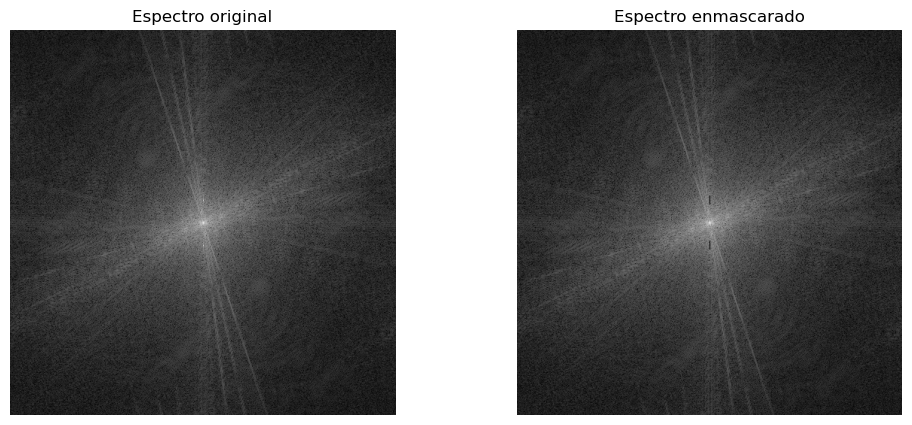

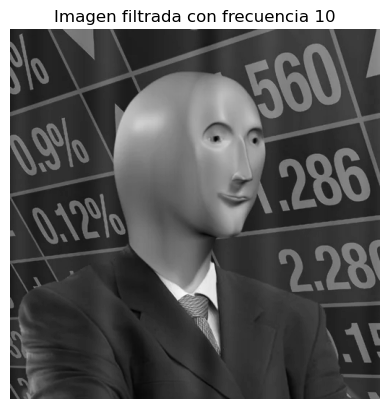

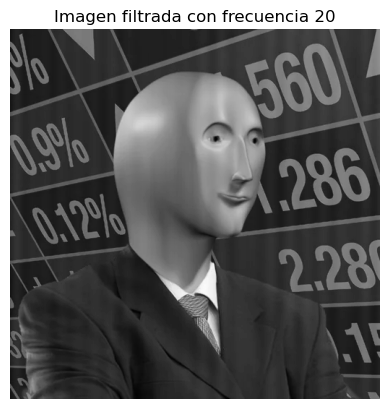

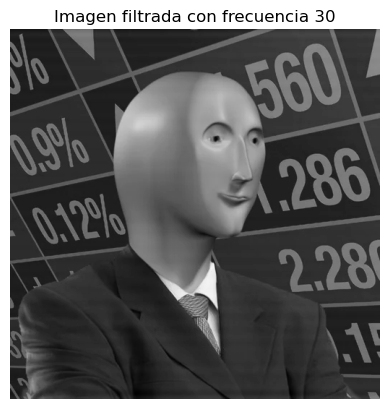

In [13]:

# Selecciona la imagen ruidosa que quieres filtrar, por ejemplo noised_images[0] para 10Hz
def filtrar_ruido_frecuencial(img_ruido, frec, radius=6, orientation=0):
    # Obtener el espectro de Fourier
    Fshift = get_star_spectrum(img_ruido)
    # Crear una máscara para bloquear los picos de ruido
    mask = np.ones_like(Fshift, dtype=np.float32)
    rows, cols = mask.shape
    crow, ccol = rows // 2, cols // 2

    if orientation == 1:
        # Ruido vertical: picos a +/-frec en eje vertical (filas)
        for f in [frec, -frec]:
            mask[crow + f - radius:crow + f + radius, ccol] = 0
            mask[crow - f - radius:crow - f + radius, ccol] = 0
    else:
        # Ruido horizontal: picos a +/-frec en eje horizontal (columnas)
        for f in [frec, -frec]:
            mask[crow, ccol + f - radius:ccol + f + radius] = 0
            mask[crow, ccol - f - radius:ccol - f + radius] = 0

    # Mostrar el espectro antes y después de la máscara
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(np.log(1 + np.abs(Fshift)), cmap='gray')
    plt.title('Espectro original')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(np.log(1 + np.abs(Fshift * mask)), cmap='gray')
    plt.title('Espectro enmascarado')
    plt.axis('off')
    plt.show()

    # Aplicar la máscara y reconstruir la imagen
    Fshift_filtered = Fshift * mask
    out = starreturn(Fshift_filtered)
    return out

# Ejemplo de uso:
out = []
for i, f in enumerate(frec):
    if f == 30:
        # Para la frecuencia 30, se aplica una rotación de 90 grados
        filtered_img = filtrar_ruido_frecuencial(noised_images[i], f, orientation=1)
    else:
        filtered_img = filtrar_ruido_frecuencial(noised_images[i], f)
    out.append(filtered_img)

#mostrar las imágenes filtradas
for i, f in enumerate(frec):
    plt.imshow(out[i], cmap='gray')
    plt.title(f'Imagen filtrada con frecuencia {f}')
    plt.axis('off')
    plt.show()
    

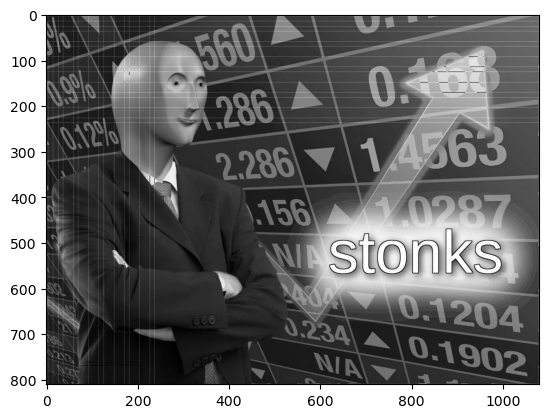

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('stonks.png',cv2.IMREAD_GRAYSCALE)
m = img.shape[0]
delta = 15
V = np.fix(np.linspace(delta,m-delta,delta)).astype('uint8')
img[V,:] = img[V,:]+50
img[:,V] = img[:,V]+50
plt.imshow(img, cmap='gray')
plt.show()

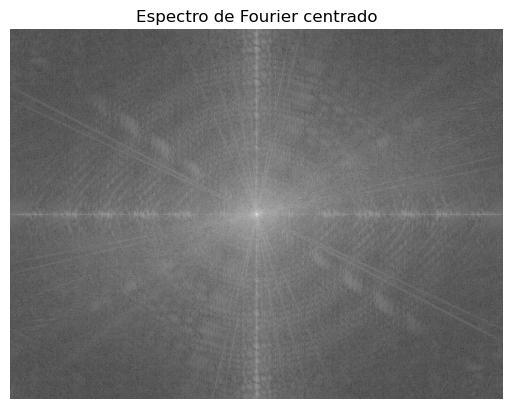

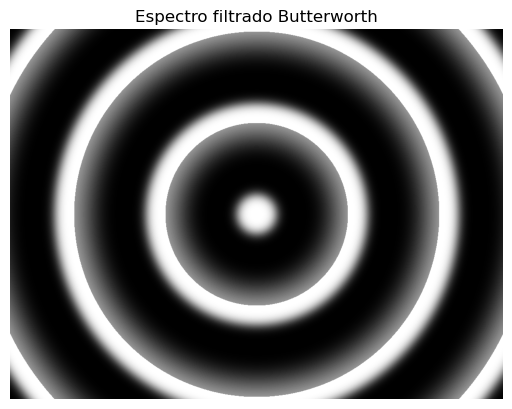

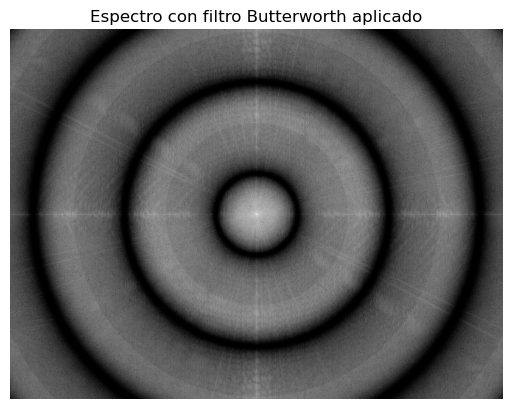

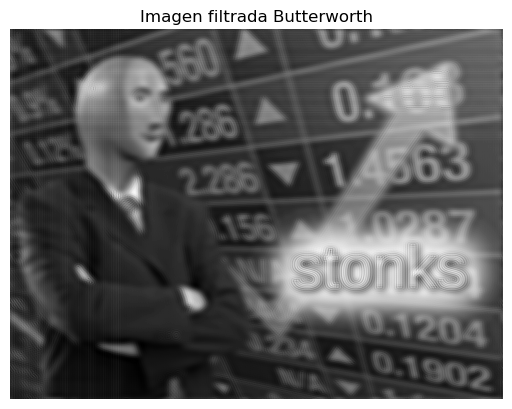

In [ ]:
# Función para obtener el espectro de Fourier centrado
spectrum = get_star_spectrum(img)
plt.imshow(np.log(1 + np.abs(spectrum)), cmap='gray')
plt.title('Espectro de Fourier centrado')
plt.axis('off')
plt.show()

# Crear un filtro pasa banda en el dominio de la frecuencia
def butterworth_bandstop_periodic(shape, fmin, fmax, n=2, period=100):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    distancia = np.sqrt((Y - crow)**2 + (X - ccol)**2)
    # Hacemos que el filtro se repita periódicamente cada 'period' píxeles
    periodic_dist = np.mod(distancia, period)
    mask = 1 / (1 + ((periodic_dist * (fmax - fmin)) / (periodic_dist**2 - fmin * fmax + 1e-6))**(2 * n))
    return mask

# Ajusta este valor para controlar la periodicidad
# Usar solo la función butterworth_bandstop_periodic y pasar valores escalares
# Ajusta los parámetros del filtro para atenuar el ruido generado por el código dado
# El ruido aparece como líneas brillantes horizontales y verticales, que en el espectro se ven como picos periódicos.
# Por lo general, la periodicidad del ruido corresponde a 'delta', así que ajusta 'period' a delta y el rango de frecuencias a bloquear alrededor de los múltiplos de esa periodicidad.

# La frecuencia en el dominio de Fourier no se mide en Hz reales, sino en "índices" de la matriz de la transformada.
# En la imagen, el tamaño (m) es 810, y la periodicidad del ruido es 'delta' = 15 píxeles.
# La frecuencia fundamental asociada a esa periodicidad es f = m / delta ≈ 54 ciclos/im.
# Sin embargo, en la matriz de la FFT, los picos de ruido aparecen en posiciones alejadas del centro por múltiplos de (m/delta).
# Por eso, los valores de fmin y fmax deben ser grandes (por ejemplo, 80-100) para cubrir los picos correspondientes a la periodicidad del ruido.
# Si el ruido fuera de baja frecuencia (periodo grande), los picos estarían cerca del centro (baja frecuencia).
# Aquí, como el ruido es periódico cada 15 píxeles, los picos están lejos del centro (alta frecuencia).

fmin = 30   # Frecuencia mínima a bloquear (ajusta según el espectro)
fmax = 200  # Frecuencia máxima a bloquear (ajusta según el espectro)
n = 2       # Orden del filtro
period = 200  # Periodicidad igual a la variable delta del código de ruido

mask_bw = butterworth_bandstop_periodic(img.shape, fmin, fmax, n=n, period=period)

# Aplicar el filtro al espectro
spectrum_bw = spectrum * mask_bw

# Visualizar el espectro filtrado
plt.imshow(np.log(1 + np.abs(mask_bw)), cmap='gray')
plt.title('Espectro filtrado Butterworth')
plt.axis('off')
plt.show()

# Mostrar el espectro después de aplicar el filtro
plt.imshow(np.log(1 + np.abs(spectrum_bw)), cmap='gray')
plt.title('Espectro con filtro Butterworth aplicado')
plt.axis('off')
plt.show()

# Reconstruir la imagen filtrada
img_bw = np.fft.ifft2(np.fft.ifftshift(spectrum_bw))
img_bw = np.abs(img_bw)
img_bw = cv2.normalize(img_bw, dst=None, alpha=0.0, beta=1.0, norm_type=cv2.NORM_MINMAX)

plt.imshow(img_bw, cmap='gray')
plt.title('Imagen filtrada Butterworth')
plt.axis('off')
plt.show()
